# FASE 2 — Red vial de La Paz

Descarga y exploración de la red vial vehicular usando datos abiertos de OpenStreetMap (sin credenciales requeridas).

**Archivos generados:**
- `data/raw/lapaz_network.gpkg` — grafo completo
- `data/raw/lapaz_edges.csv` — aristas con atributos
- `data/raw/lapaz_network_preview.png` — mapa estático de verificación

## 1. Importaciones

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"osmnx v{ox.__version__}")
print(f"geopandas v{gpd.__version__}")

osmnx v2.1.0
geopandas v1.1.3


## 2. Descarga de la red vial

Se intenta primero por nombre de lugar. Si falla (timeout o geocodificación), se usa un bounding box manual de La Paz.

In [2]:
ox.settings.timeout = 180

try:
    G = ox.graph_from_place("La Paz, Bolivia", network_type="drive")
    print("✓ Red descargada por nombre de lugar")
except Exception as e:
    print(f"Fallo por nombre de lugar: {e}")
    print("→ Intentando con bounding box manual...")
    G = ox.graph_from_bbox(
        bbox=(-16.46, -16.56, -68.08, -68.18),
        network_type="drive"
    )
    print("✓ Red descargada por bounding box manual")

✓ Red descargada por nombre de lugar


## 3. Estadísticas básicas

In [3]:
nodes, edges = ox.graph_to_gdfs(G)

print(f"Nodos (intersecciones): {len(nodes):,}")
print(f"Aristas (segmentos viales): {len(edges):,}")
print()

highway_counts = edges["highway"].explode().value_counts()
print("Tipos de vía:")
print(highway_counts.to_string())
print()
print(f"Longitud total de la red: {edges['length'].sum() / 1000:.1f} km")

Nodos (intersecciones): 14,650
Aristas (segmentos viales): 37,100

Tipos de vía:
highway
residential       29451
secondary          2938
tertiary           2105
primary            1188
unclassified        654
trunk               229
living_street       226
secondary_link      207
primary_link         88
tertiary_link        72
motorway             11
motorway_link         3
trunk_link            2
bus_stop              1

Longitud total de la red: 4035.2 km


## 4. Guardado como GeoPackage

In [4]:
raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

gpkg_path = raw_dir / "lapaz_network.gpkg"
ox.save_graph_geopackage(G, filepath=str(gpkg_path))
print(f"✓ GeoPackage guardado: {gpkg_path} ({gpkg_path.stat().st_size / 1024 / 1024:.1f} MB)")

✓ GeoPackage guardado: ../data/raw/lapaz_network.gpkg (7.8 MB)


## 5. Guardado de aristas como CSV

In [5]:
cols = ["osmid", "name", "highway", "length", "geometry", "u", "v"]
edges_reset = edges.reset_index()
edges_df = edges_reset[[c for c in cols if c in edges_reset.columns]].copy()
edges_df["geometry"] = edges_df["geometry"].astype(str)

csv_path = raw_dir / "lapaz_edges.csv"
edges_df.to_csv(csv_path, index=False)
print(f"✓ CSV guardado: {csv_path}")
print(f"  Filas: {len(edges_df):,}  |  Columnas: {list(edges_df.columns)}")
edges_df.head(3)

/tmp/ipykernel_221671/2921140569.py:4: UserWarning: Geometry column does not contain geometry.
  edges_df["geometry"] = edges_df["geometry"].astype(str)


✓ CSV guardado: ../data/raw/lapaz_edges.csv
  Filas: 37,100  |  Columnas: ['osmid', 'name', 'highway', 'length', 'geometry', 'u', 'v']


,osmid,name,highway,length,geometry,u,v
0,"[262417640, 497941587, 497941588]",Autopista Héroes de la Guerra del Chaco,motorway,2850.136643,"LINESTRING (-68.16299 -16.499575, -68.163051 -...",271098339,10609339990
1,"[1452753093, 1452753094]",Autopista Héroes de la Guerra del Chaco,motorway,228.409977,"LINESTRING (-68.149329 -16.46286, -68.150264 -...",271099231,13323193854
2,1493450218,NaN,tertiary,49.382943,"LINESTRING (-68.149329 -16.46286, -68.149548 -...",271099231,13684985604


## 6. Visualización estática de verificación

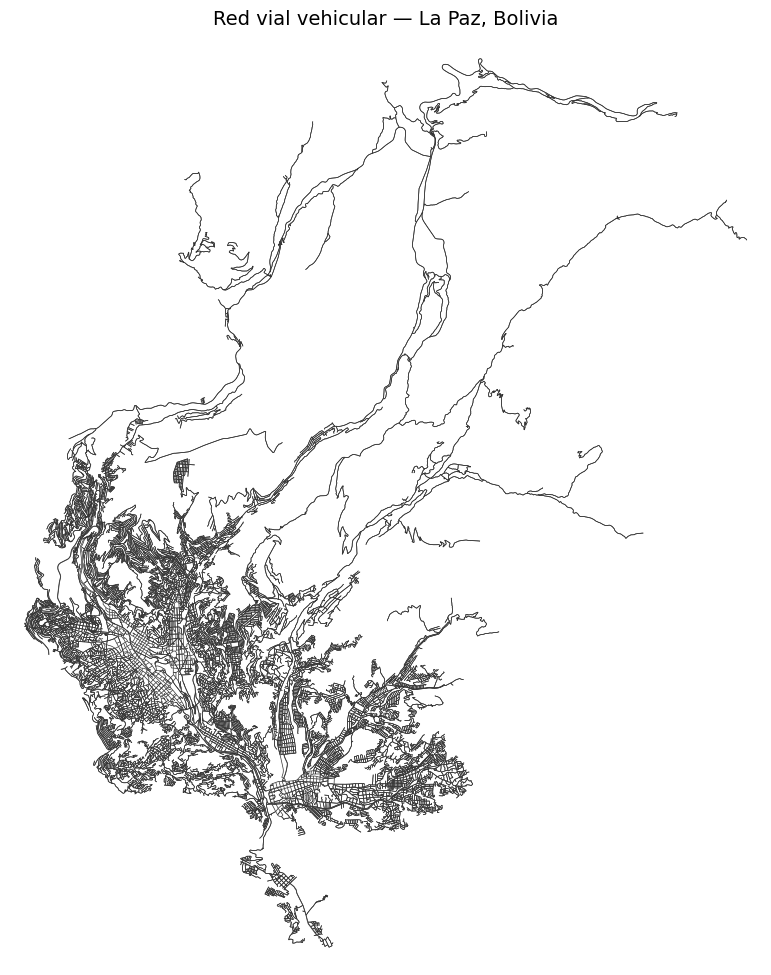

✓ Preview guardado: ../data/raw/lapaz_network_preview.png


In [6]:
fig, ax = ox.plot_graph(
    G,
    figsize=(12, 12),
    node_size=0,
    edge_linewidth=0.5,
    edge_color="#333333",
    bgcolor="white",
    show=False,
    close=False
)
ax.set_title("Red vial vehicular — La Paz, Bolivia", fontsize=14, pad=12)

preview_path = raw_dir / "lapaz_network_preview.png"
fig.savefig(str(preview_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Preview guardado: {preview_path}")

## 7. Resumen final de la fase

In [7]:
print("=" * 40)
print("RESUMEN FASE 2 — Red vial de La Paz")
print("=" * 40)
print(f"Nodos (intersecciones): {len(nodes):,}")
print(f"Aristas (segmentos):    {len(edges_df):,}")
print(f"Tipos de vía únicos:    {edges['highway'].explode().nunique()}")
print(f"Longitud total de red:  {edges['length'].sum() / 1000:.1f} km")
print()
print("Archivos generados:")
for f in ["lapaz_network.gpkg", "lapaz_edges.csv", "lapaz_network_preview.png"]:
    p = raw_dir / f
    size_kb = p.stat().st_size / 1024
    if size_kb >= 1024:
        print(f"  ✓ data/raw/{f} ({size_kb / 1024:.1f} MB)")
    else:
        print(f"  ✓ data/raw/{f} ({size_kb:.0f} KB)")

RESUMEN FASE 2 — Red vial de La Paz
Nodos (intersecciones): 14,650
Aristas (segmentos):    37,100
Tipos de vía únicos:    14
Longitud total de red:  4035.2 km

Archivos generados:
  ✓ data/raw/lapaz_network.gpkg (7.8 MB)
  ✓ data/raw/lapaz_edges.csv (8.0 MB)
  ✓ data/raw/lapaz_network_preview.png (617 KB)
